# CAMM Hackathon #10: STEM Image Restoration

STEM image credits: Austin Houston


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
!gdown https://drive.google.com/file/d/14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs
To: /content/graphene_2.h5
100% 17.1M/17.1M [00:00<00:00, 43.9MB/s]


In [3]:
!gdown https://drive.google.com/file/d/1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN/view?usp=drive_link --fuzzy

Downloading...
From: https://drive.google.com/uc?id=1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN
To: /content/HAADF_21.h5
100% 4.53M/4.53M [00:00<00:00, 28.3MB/s]


In [4]:
#@title h5 load
def save_dict_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'w') as f:
        _recursively_save(f, data_dict)

def _recursively_save(group, data):
    if isinstance(data, dict):
        for key, value in data.items():
            subgroup = group.create_group(str(key))
            _recursively_save(subgroup, value)

    elif isinstance(data, list):
        # Turn list into group with numerical keys
        for i, item in enumerate(data):
            subgroup = group.create_group(str(i))
            _recursively_save(subgroup, item)

    elif isinstance(data, np.ndarray):
        if data.dtype == object:
            # convert each element to string (json)
            data_as_str = np.array([json.dumps(x) for x in data], dtype='S256')
            group.create_dataset('value', data=data_as_str)
        else:
            group.create_dataset('value', data=data)

    elif isinstance(data, (int, float, np.int_, np.float_)):
        group.create_dataset('value', data=data)

    elif data is None:
        group.attrs['value'] = 'None'

    else:
        # Fallback: convert unknown object to JSON string
        group.create_dataset('value', data=json.dumps(data))


def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)



def _load_item(obj):
    """
    Load any HDF5 object (Group or Dataset) and reconstruct Python object.
    """
    # ---------------------------------------------------------
    # CASE 1 — HDF5 GROUP  (recursive dict or list)
    # ---------------------------------------------------------
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())

        # Empty group → return None or empty dict
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}

        # Detect list: all keys are integers
        if all(k.isdigit() for k in keys):
            lst = []
            for k in sorted(keys, key=lambda x: int(x)):
                lst.append(_load_item(obj[k]))
            return lst

        # Regular dictionary
        out = {}
        for k in keys:
            out[k] = _load_item(obj[k])

        # Special case: group representing None
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None

        return out

    # ---------------------------------------------------------
    # CASE 2 — HDF5 DATASET  (arrays / scalars / strings)
    # ---------------------------------------------------------
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]

        # Scalar
        if np.isscalar(data):
            return data

        # Byte strings → JSON or text
        if isinstance(data, (bytes, np.bytes_)):
            try:
                return json.loads(data.decode())
            except:
                return data.decode()

        # Array of byte strings
        if data.dtype.kind == "S":
            try:
                return [json.loads(x.decode()) for x in data]
            except:
                return [x.decode() for x in data]

        # Normal numpy array
        return data

    # ---------------------------------------------------------
    # CASE 3 — Attributes marking None
    # ---------------------------------------------------------
    else:
        raise ValueError("Unknown HDF5 object type:", obj)


def get_arr(runs, key):
    """
    Extract numpy array from runs[key], automatically handling nested {'value': array}.
    """
    val = runs[key]
    if isinstance(val, dict) and "value" in val:
        return np.asarray(val["value"])
    return np.asarray(val)



In [5]:
#@title masking functions
from scipy.ndimage import binary_dilation
from skimage.draw import line as draw_line

def mask_below_line(im, row=None, frac=0.6, above=True):
    """
    Mask all pixels below (or above) a horizontal threshold row.

    Parameters
    ----------
    im : 2D array
    row   : int, absolute row index. Defaults to frac * H.
    frac  : float, fraction of height for the cut if row is None.
    above : bool, if True mask everything above the line instead.

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    H, W = im.shape
    if row is None:
        row = int(frac * H)
    mask = np.zeros((H, W), dtype=bool)
    if above:
        mask[:row, :] = True
    else:
        mask[row:, :] = True
    return mask

def mask_lakes(im, n_lakes=10, size_range=(10, 220), aspect_range=(0.5, 4.0),
               roughness=0.8, n_harmonics=34, seed=None):
    """
    Lake regions with ragged / torn borders, arranged in a loose cluster.

    The border is a polar curve whose radius is modulated by a sum of random
    sinusoids, producing irregular, non-repeating jagged edges.

    Parameters
    ----------
    im : 2D array
    n_lakes      : number of lakes
    size_range   : (min, max) semi-major axis in pixels
    aspect_range : (min, max) aspect ratio (semi-major / semi-minor)
    roughness    : 0 = smooth ellipse, 1 = very jagged (good range: 0.2–0.6)
    n_harmonics  : number of sinusoidal harmonics added to the border
    seed         : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    # loose cluster centre
    cy_c = rng.integers(H // 4, 3 * H // 4)
    cx_c = rng.integers(W // 4, 3 * W // 4)
    spread = max(H, W) // 4

    yy, xx = np.mgrid[:H, :W]

    for _ in range(n_lakes):
        cy = int(np.clip(rng.normal(cy_c, spread), 0, H - 1))
        cx = int(np.clip(rng.normal(cx_c, spread), 0, W - 1))
        a = rng.integers(*size_range)           # semi-major
        aspect = rng.uniform(*aspect_range)
        b = max(1, int(a / aspect))             # semi-minor
        angle = rng.uniform(0, np.pi)

        # rotate coordinates
        dy = yy - cy
        dx = xx - cx
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        u = cos_a * dx + sin_a * dy             # along major axis
        v = -sin_a * dx + cos_a * dy            # along minor axis

        # polar angle of every pixel relative to lake centre
        theta = np.arctan2(v, u)

        # ragged radius envelope: 1 + sum of random harmonics
        freqs = rng.integers(2, n_harmonics + 2, size=n_harmonics)
        amps  = rng.uniform(0, roughness / n_harmonics, size=n_harmonics)
        phases = rng.uniform(0, 2 * np.pi, size=n_harmonics)
        envelope = 1.0 + sum(
            amp * np.sin(freq * theta + phase)
            for amp, freq, phase in zip(amps, freqs, phases)
        )

        # pixel is inside if its normalised ellipse distance < ragged envelope
        dist = np.sqrt((u / a) ** 2 + (v / b) ** 2)
        mask |= dist <= envelope

    return ~mask

def mask_lines(im, n_lines=80, thickness=4, orientation="horizontal", seed=None):
    """
    Thin random straight lines across the image (horizontal, vertical, or diagonal).

    Parameters
    ----------
    im : 2D array
    n_lines     : number of lines
    thickness   : line width in pixels (via dilation)
    orientation : "horizontal" | "vertical" | "diagonal" | "mixed"
    seed        : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    orientations = ["horizontal", "vertical", "diagonal"]

    for _ in range(n_lines):
        if orientation == "mixed":
            ort = rng.choice(orientations)
        else:
            ort = orientation

        if ort == "horizontal":
            r = rng.integers(0, H)
            mask[r, :] = True
        elif ort == "vertical":
            c = rng.integers(0, W)
            mask[:, c] = True
        else:  # diagonal
            r0, c0 = rng.integers(0, H), rng.integers(0, W)
            r1, c1 = rng.integers(0, H), rng.integers(0, W)
            rr, cc = draw_line(r0, c0, r1, c1)
            valid = (rr >= 0) & (rr < H) & (cc >= 0) & (cc < W)
            mask[rr[valid], cc[valid]] = True

    if thickness > 1:
        struct = np.ones((thickness, thickness), dtype=bool)
        mask = binary_dilation(mask, structure=struct)

    return ~mask

def mask_small_blobs(im, n_blobs=300, size_range=(1, 24), seed=None):
    """
    Many tiny blobs simulating dead-pixel clusters or dust on the detector.

    Parameters
    ----------
    im      : 2D array
    n_blobs    : number of small blobs
    size_range : (min_r, max_r) radius in pixels
    seed       : RNG seed

    Returns
    -------
    mask : bool ndarray (H, W)
    """
    rng = np.random.default_rng(seed)
    H, W = im.shape
    mask = np.zeros((H, W), dtype=bool)

    yy, xx = np.ogrid[:H, :W]

    for _ in range(n_blobs):
        cy = rng.integers(0, H)
        cx = rng.integers(0, W)
        r = rng.integers(*size_range)
        mask |= (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2

    return ~mask

In [6]:
data = load_hdf5_to_dict('/content/graphene_2.h5')
data_more = load_hdf5_to_dict('/content/HAADF_21.h5')

im0 = data['Measurement_000']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im1 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, :1000]
im2 = data['Measurement_001']['Channel_000']['HAADF']['HAADF'][:1000, -1000:]
im3 = data_more['Measurement_000']['Channel_000']['HAADF']['HAADF']

ims = [im0, im1, im2, im3]

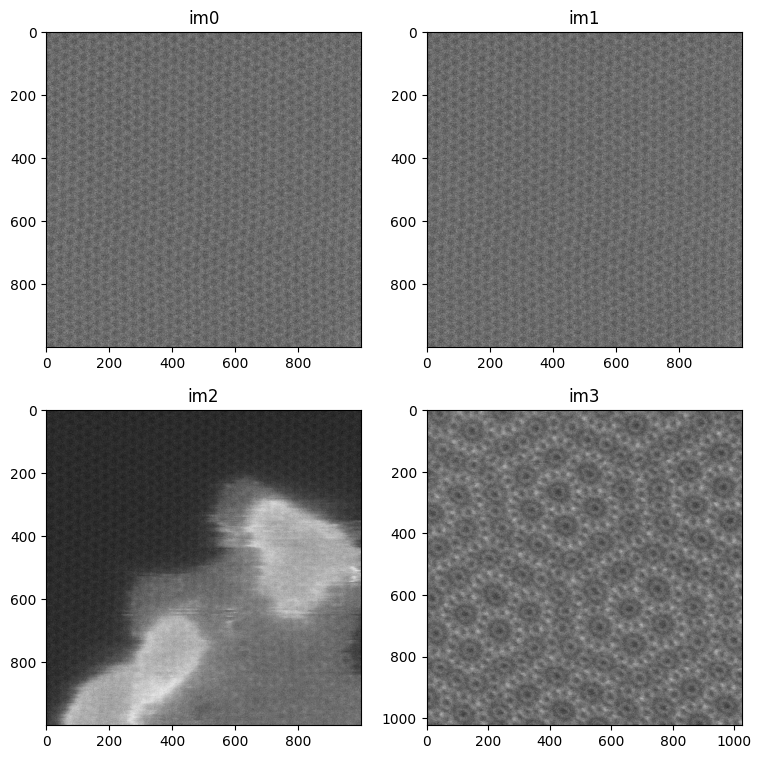

In [7]:
fig, axes = plt.subplots(2,2, figsize=(9,9))

ax = axes.flatten()

for i, _ in enumerate(ax):
  _.imshow(ims[i], cmap='gray')
  _.set_title(f'im{i}')

Text(0.5, 1.0, 'mask_small_blobs()')

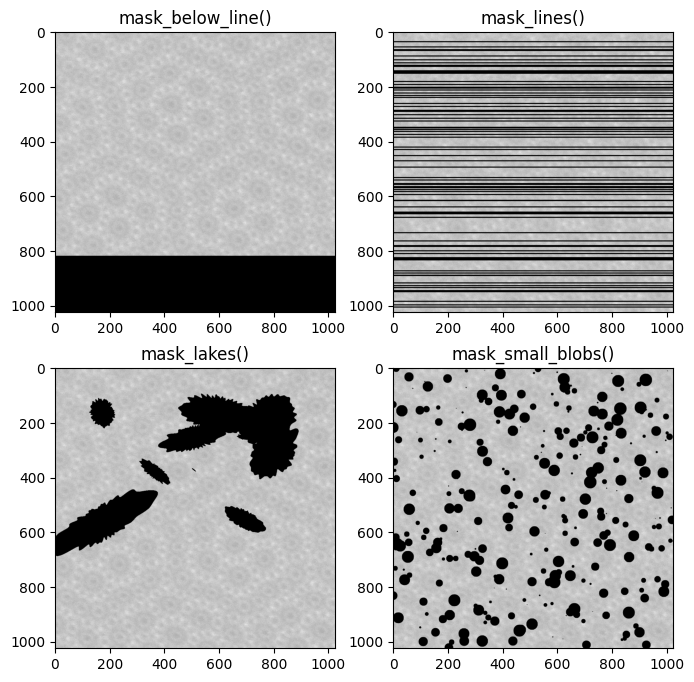

In [8]:
fig, ax = plt.subplots(2,2, figsize=(8,8))


ax[0,0].imshow(mask_below_line(im3, frac=0.8)*im3, cmap='gray')
ax[0,0].set_title('mask_below_line()')

ax[0,1].imshow(mask_lines(im3)*im3, cmap='gray')
ax[0,1].set_title('mask_lines()')

ax[1,0].imshow(mask_lakes(im3)*im3, cmap='gray')
ax[1,0].set_title('mask_lakes()')

ax[1,1].imshow(mask_small_blobs(im3)*im3, cmap='gray')
ax[1,1].set_title('mask_small_blobs()')


# Given a 2D microscopy intensity array and a binary loss mask, reconstruct missing regions and estimate prediction uncertainty

## Solution v3 — Physics-Informed + Non-Local + Ensemble

**Root causes of v2 plateau:**
1. Crystal-Aware detected 445 noise peaks instead of 6–12 true lattice vectors
2. Methods work independently — no information sharing across approaches
3. U-Net sees only the local masked input, not the crystal periodicity structure

**v3 fixes:**
- `find_lattice_vectors()` — robust autocorrelation-based detection, ≤8 peaks
- `iterative_crystal_inpaint()` — iterative propagation (fills large gaps like Below-line)
- `patch_nlm_inpaint()` — non-local patch matching (best for self-similar periodic textures)
- `physics_postprocess()` — post-process ANY method with crystal periodicity constraint
- `ensemble_inpaint()` — adaptive weighted ensemble of all methods

In [ ]:
# ── Imports ────────────────────────────────────────────────────────────────
import torch, torch.nn as nn, torch.nn.functional as F_, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from skimage.restoration import inpaint_biharmonic
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from scipy.ndimage import maximum_filter, uniform_filter
import time, warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


In [ ]:
def normalize_01(im):
    mn, mx = im.min(), im.max()
    return (im - mn) / (mx - mn + 1e-8)

def compute_metrics(original, reconstructed, mask):
    o = normalize_01(original.astype(float))
    r = normalize_01(reconstructed.astype(float))
    missing = ~mask
    s   = ssim_metric(o, r, data_range=1.0)
    p   = psnr_metric(o, r, data_range=1.0)
    mse = float(np.mean((o[missing] - r[missing])**2)) if missing.any() else 0.0
    return {'SSIM': s, 'PSNR (dB)': p, 'MSE (missing)': mse}

def warm_start(image, mask):
    """Fill missing pixels with per-row mean of valid pixels (better than zeros)."""
    H, W = image.shape
    init = image.copy()
    gm   = image[mask].mean() if mask.any() else 0.5
    for r in range(H):
        vals = image[r, mask[r]]
        init[r, ~mask[r]] = vals.mean() if vals.size > 0 else gm
    return init


In [ ]:
N       = 256
im_test = normalize_01(im3[:N, :N].astype(float))
SEED    = 42

masks_dict = {
    'Lines'      : mask_lines(im_test,       n_lines=15, thickness=3, seed=SEED),
    'Lakes'      : mask_lakes(im_test,       n_lakes=5,  size_range=(10, 45), seed=SEED),
    'Blobs'      : mask_small_blobs(im_test, n_blobs=50, size_range=(1, 12),  seed=SEED),
    'Below-line' : mask_below_line(im_test,  frac=0.75),
}
masked_dict = {k: v.astype(float) * im_test for k, v in masks_dict.items()}

print(f"{'Mask':<12}  {'Missing %':>10}  {'Missing px':>12}")
print("-" * 38)
for k, m in masks_dict.items():
    pct = 100 * (~m).mean()
    print(f"{k:<12}  {pct:>9.1f}%  {(~m).sum():>12,}")


---
### Shared Utility: Robust Lattice Vector Detection

The v2 Crystal-Aware detected **445 noise peaks**. Root cause: the power spectrum threshold `0.02 * max` passes noise. 

Fix: use **masked autocorrelation** (robust to missing pixels) + strict dual filter — strong peak value AND minimum inter-peak separation equal to the expected lattice period.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# SHARED: Robust Lattice Vector Detection
# ════════════════════════════════════════════════════════════════════════════
def find_lattice_vectors(image, mask, n_max=6):
    """
    Detect crystal lattice vectors via masked autocorrelation.

    Key improvement over v2: strict peak filtering keeps only the
    2–6 fundamental lattice reflections (not 445 noise peaks).

    Returns
    -------
    lvecs : (K, 2) array of (dy, dx) lattice shifts in pixels
    """
    H, W = image.shape
    valid_im = image * mask

    # ── Autocorrelation via power spectrum ───────────────────────────────────
    F  = np.fft.fft2(valid_im)
    ac = np.real(np.fft.ifft2(np.abs(F) ** 2))
    ac = np.fft.fftshift(ac)
    ac = ac / (ac.max() + 1e-8)
    cy, cx = H // 2, W // 2

    # ── Search band: exclude DC and very long-range correlations ─────────────
    # Expected lattice period: 3% – 30% of image size
    min_d = max(3, int(0.03 * min(H, W)))
    max_d = int(0.30 * min(H, W))

    ac_search = ac.copy()
    # Suppress DC
    ac_search[cy - min_d: cy + min_d, cx - min_d: cx + min_d] = 0
    # Suppress very long-range (noise floor)
    yy, xx = np.ogrid[:H, :W]
    dist_from_center = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    ac_search[dist_from_center > max_d] = 0

    # ── Peak finding with strict threshold and minimum separation ────────────
    sep    = min_d * 2                          # minimum pixels between peaks
    lm     = maximum_filter(ac_search, size=sep)
    peaks  = (ac_search == lm) & (ac_search > 0.12)   # strict: top 12% of AC
    pyx    = np.argwhere(peaks) - np.array([cy, cx])
    pvals  = ac_search[peaks]

    if pvals.size == 0:
        return np.array([[H // 10, 0], [0, W // 10]])  # fallback grid

    # ── Keep top peaks; discard redundant opposite-sign duplicates ───────────
    order  = np.argsort(-pvals)
    pyx    = pyx[order]
    pvals  = pvals[order]

    unique = []
    for v in pyx:
        is_dup = any(np.linalg.norm(v + u) < sep for u in unique)  # v ≈ -u?
        if not is_dup:
            unique.append(v)
        if len(unique) >= n_max:
            break

    return np.array(unique) if unique else np.array([[H // 10, 0], [0, W // 10]])


def make_shifts(lvecs, H, W, n_harm=3):
    """Generate all integer-harmonic shifts of the lattice vectors."""
    shifts = set()
    for v in lvecs:
        for n in range(1, n_harm + 1):
            for sign in [1, -1]:
                dy = int(sign * n * v[0]) % H
                dx = int(sign * n * v[1]) % W
                if (dy, dx) != (0, 0):
                    shifts.add((dy, dx))
    return list(shifts)


---
### Method 1 — Biharmonic (Baseline)

In [ ]:
def biharmonic_inpaint(image, mask):
    return inpaint_biharmonic(image, ~mask, channel_axis=None), np.zeros_like(image)

print("Biharmonic …")
biharmonic_results = {}
for name, mask in masks_dict.items():
    t0 = time.time()
    recon, unc = biharmonic_inpaint(masked_dict[name], mask)
    m = compute_metrics(im_test, recon, mask)
    biharmonic_results[name] = {'recon': recon, 'unc': unc, 'metrics': m}
    print(f"  {name:<12} SSIM={m['SSIM']:.4f}  PSNR={m['PSNR (dB)']:.2f} dB  ({time.time()-t0:.1f}s)")


---
### Method 2 — FFT / POCS (Fixed warm-start from v2)

In [ ]:
def fft_pocs_inpaint(image, mask, n_iter=400, keep_frac=0.10):
    recon = warm_start(image, mask)
    for _ in range(n_iter):
        F       = np.fft.fft2(recon)
        thresh  = np.percentile(np.abs(F), (1 - keep_frac) * 100)
        F_sp    = F * (np.abs(F) >= thresh)
        recon_f = np.real(np.fft.ifft2(F_sp))
        recon   = mask * image + (~mask) * recon_f
    return np.clip(recon, 0, 1)

def pocs_uncertainty(image, mask, n_boot=12, kf_range=(0.06, 0.16), n_iter=250):
    preds = [fft_pocs_inpaint(image, mask, n_iter=n_iter, keep_frac=kf)
             for kf in np.linspace(*kf_range, n_boot)]
    st = np.stack(preds)
    return st.mean(0), st.std(0)

print("FFT/POCS …")
pocs_results = {}
for name, mask in masks_dict.items():
    t0 = time.time()
    recon, unc = pocs_uncertainty(masked_dict[name], mask)
    m = compute_metrics(im_test, recon, mask)
    pocs_results[name] = {'recon': recon, 'unc': unc, 'metrics': m}
    print(f"  {name:<12} SSIM={m['SSIM']:.4f}  PSNR={m['PSNR (dB)']:.2f} dB  ({time.time()-t0:.1f}s)")


---
### Method 3 — U-Net with SSIM+MSE Loss (from v2)

In [ ]:
def ssim_loss(pred, target, ws=7):
    C1, C2 = 0.01**2, 0.03**2
    kw = dict(kernel_size=ws, stride=1, padding=ws//2)
    mu_p  = F_.avg_pool2d(pred,   **kw);  mu_t  = F_.avg_pool2d(target, **kw)
    mu_p2, mu_t2, mu_pt = mu_p**2, mu_t**2, mu_p*mu_t
    sg_p  = F_.avg_pool2d(pred**2,       **kw) - mu_p2
    sg_t  = F_.avg_pool2d(target**2,     **kw) - mu_t2
    sg_pt = F_.avg_pool2d(pred*target,   **kw) - mu_pt
    ssim_map = ((2*mu_pt+C1)*(2*sg_pt+C2)) / ((mu_p2+mu_t2+C1)*(sg_p+sg_t+C2))
    return 1 - ssim_map.mean()

def combined_loss(pred, target, mask_ch, a=0.7):
    return a * F_.mse_loss(pred*(1-mask_ch), target*(1-mask_ch)) + (1-a)*ssim_loss(pred, target)

class DoubleConv(nn.Module):
    def __init__(self, i, o, d=0.2):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(i,o,3,padding=1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True), nn.Dropout2d(d),
            nn.Conv2d(o,o,3,padding=1,bias=False), nn.BatchNorm2d(o), nn.ReLU(True))
    def forward(self,x): return self.b(x)

class UNet(nn.Module):
    def __init__(self, base=32, d=0.2):
        super().__init__()
        self.pool=nn.MaxPool2d(2)
        self.e1=DoubleConv(2,base,d);    self.e2=DoubleConv(base,base*2,d)
        self.e3=DoubleConv(base*2,base*4,d); self.bt=DoubleConv(base*4,base*8,d)
        self.u3=nn.ConvTranspose2d(base*8,base*4,2,2); self.d3=DoubleConv(base*8,base*4,d)
        self.u2=nn.ConvTranspose2d(base*4,base*2,2,2); self.d2=DoubleConv(base*4,base*2,d)
        self.u1=nn.ConvTranspose2d(base*2,base,2,2);   self.d1=DoubleConv(base*2,base,d)
        self.out=nn.Sequential(nn.Conv2d(base,1,1),nn.Sigmoid())
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); b=self.bt(self.pool(e3))
        d=self.d3(torch.cat([self.u3(b),e3],1)); d=self.d2(torch.cat([self.u2(d),e2],1))
        d=self.d1(torch.cat([self.u1(d),e1],1)); return self.out(d)

class PatchDS(Dataset):
    def __init__(self, imgs, patch=64, n=3000, seed=0):
        rng=np.random.default_rng(seed); self.data=[]
        for im in imgs:
            H,W=im.shape
            for _ in range(n//len(imgs)):
                r=rng.integers(0,H-patch); c=rng.integers(0,W-patch)
                self.data.append(im[r:r+patch,c:c+patch].astype(np.float32))
    def __len__(self): return len(self.data)
    def __getitem__(self,i):
        p=self.data[i]; ch=np.random.randint(3)
        if   ch==0: m=mask_lines(p,n_lines=np.random.randint(3,15))
        elif ch==1: m=mask_small_blobs(p,n_blobs=np.random.randint(10,50))
        else:       m=mask_lakes(p,n_lakes=np.random.randint(1,4),size_range=(5,20))
        m=m.astype(np.float32)
        return torch.from_numpy(np.stack([p*m,m])), torch.from_numpy(p[None])

def train_unet(images, epochs=50, batch=16, lr=3e-4):
    model=UNet().to(device); opt=optim.Adam(model.parameters(),lr=lr)
    sched=optim.lr_scheduler.CosineAnnealingLR(opt,epochs)
    loader=DataLoader(PatchDS(images),batch_size=batch,shuffle=True,num_workers=0,
                      pin_memory=(device.type=='cuda'))
    model.train()
    for ep in range(1,epochs+1):
        ls=[]
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            pred=model(x); loss=combined_loss(pred,y,x[:,1:2])
            opt.zero_grad(); loss.backward(); opt.step(); ls.append(loss.item())
        sched.step()
        if ep%10==0 or ep==1: print(f"  Epoch {ep:>3}/{epochs}  loss={np.mean(ls):.5f}")
    return model

def unet_predict(model, image, mask, n_mc=30):
    model.train()
    x=torch.from_numpy(np.stack([image*mask, mask.astype(np.float32)]).astype(np.float32)[None]).to(device)
    with torch.no_grad(): preds=np.stack([model(x).squeeze().cpu().numpy() for _ in range(n_mc)])
    mean=preds.mean(0); recon=mask*image+(~mask)*mean
    return np.clip(recon,0,1), preds.std(0)

all_imgs=[normalize_01(im.astype(float)) for im in ims]
print("Training U-Net …")
t0=time.time(); unet=train_unet(all_imgs,epochs=50); print(f"Done {time.time()-t0:.1f}s\n")

print("U-Net inference …")
unet_results={}
for name,mask in masks_dict.items():
    recon,unc=unet_predict(unet,im_test,mask)
    m=compute_metrics(im_test,recon,mask)
    unet_results[name]={'recon':recon,'unc':unc,'metrics':m}
    print(f"  {name:<12} SSIM={m['SSIM']:.4f}  PSNR={m['PSNR (dB)']:.2f} dB")


---
### Method 4 — Iterative Crystal Inpainting (v3 Fix)

**Problem with v2:** single-pass shift-averaging only propagates information one lattice step at a time. Large missing regions (Below-line, Lakes) need multi-hop propagation.

**Fix:** iterate — each round lets freshly reconstructed pixels contribute to the next round, allowing information to "flow" across large gaps like Below-line.

In [ ]:
def iterative_crystal_inpaint(image, mask, n_iter=12, n_harm=4, n_boot=12):
    """
    Iterative Crystal-Aware Inpainting.

    Each iteration:
      1. Shift-average using BOTH original valid pixels AND previously
         reconstructed (confident) pixels  ← key fix over v2
      2. Update the set of trusted pixels

    This propagates crystal structure across large missing regions.
    """
    H, W    = image.shape
    lvecs   = find_lattice_vectors(image, mask)
    shifts  = make_shifts(lvecs, H, W, n_harm=n_harm)
    print(f"    Lattice vectors: {len(lvecs)}  |  Total shifts: {len(shifts)}")

    valid_im = image * mask
    recon    = warm_start(image, mask)
    # Confidence: 1 = definitely valid, grows as we reconstruct
    conf     = mask.astype(float).copy()

    for it in range(n_iter):
        # Build the current "trusted" image (original + confident reconstructed)
        trusted_im   = mask * image + (~mask) * recon
        trusted_mask = mask | (conf > 0.4)       # includes high-confidence recon'd pixels

        accum = trusted_im * trusted_mask
        count = trusted_mask.astype(float)

        for dy, dx in shifts:
            s_im = np.roll(np.roll(trusted_im,          dy, 0), dx, 1)
            s_mk = np.roll(np.roll(trusted_mask.astype(float), dy, 0), dx, 1)
            accum += s_im * s_mk
            count += s_mk

        fill  = np.where(count > 0, accum / np.maximum(count, 1e-8), recon)
        recon = mask * image + (~mask) * fill     # always pin original known pixels
        # Update confidence: more shifts contributing → higher confidence
        conf  = np.clip(count / (len(shifts) + 1), 0, 1)

    # Bootstrap uncertainty (vary subset of shifts)
    rng   = np.random.default_rng(0)
    preds = []
    for _ in range(n_boot):
        sub   = [shifts[i] for i in rng.choice(len(shifts), max(1,len(shifts)//2), replace=False)]
        acc2  = image*mask; cnt2 = mask.astype(float)
        for dy,dx in sub:
            acc2 += np.roll(np.roll(image*mask,dy,0),dx,1)
            cnt2 += np.roll(np.roll(mask.astype(float),dy,0),dx,1)
        f = np.where(cnt2>0, acc2/np.maximum(cnt2,1e-8), recon)
        preds.append(mask*image+(~mask)*f)
    unc = np.stack(preds).std(0)

    return np.clip(recon, 0, 1), unc

print("Iterative Crystal Inpainting …")
crystal_results = {}
for name, mask in masks_dict.items():
    t0 = time.time()
    recon, unc = iterative_crystal_inpaint(im_test, mask)
    m = compute_metrics(im_test, recon, mask)
    crystal_results[name] = {'recon': recon, 'unc': unc, 'metrics': m}
    print(f"  {name:<12} SSIM={m['SSIM']:.4f}  PSNR={m['PSNR (dB)']:.2f} dB  ({time.time()-t0:.1f}s)")


---
### Method 5 — Non-Local Patch Matching (New)

For self-similar periodic textures (graphene, any crystal), **every valid region is a template** for every missing region. Non-local patch matching:
1. Builds a dictionary of valid patches from the entire image
2. For each missing patch, finds the K most similar valid patches (using only the known pixels for comparison)
3. Fills missing pixels via weighted average of the K best matches

This is especially powerful for **large contiguous gaps** (Below-line, Lakes) because it reaches across the whole image for matching patches.

In [ ]:
def patch_nlm_inpaint(image, mask, patch_size=16, n_best=7,
                      dict_step=4, query_step=4):
    """
    Non-Local Patch Matching Inpainting for periodic/textured images.

    Algorithm
    ---------
    1.  Extract all valid patches (≥90% known pixels) into a dictionary.
    2.  For each patch position that overlaps the missing region, find the
        n_best dictionary patches whose *known* pixels best match.
    3.  Blend the top matches; accumulate over overlapping patches.

    Complexity: O(|queries| × |dict| × patch_size²) — fast with numpy.
    """
    H, W = image.shape
    ps, hp = patch_size, patch_size // 2

    # ── Build patch dictionary ───────────────────────────────────────────────
    VP_list, VP_pos = [], []
    for r in range(hp, H - hp, dict_step):
        for c in range(hp, W - hp, dict_step):
            pm = mask[r-hp:r+hp, c-hp:c+hp]
            if pm.mean() > 0.90:
                VP_list.append(image[r-hp:r+hp, c-hp:c+hp])
                VP_pos.append((r, c))

    if not VP_list:
        return image, np.zeros_like(image)

    VP      = np.stack(VP_list)               # (N, ps, ps)
    VP_flat = VP.reshape(len(VP), -1)         # (N, ps²)
    N       = len(VP)
    print(f"    Dictionary: {N} valid patches")

    accum  = (image * mask).copy()
    weight = mask.astype(float).copy()

    # ── For each query patch, find best matches ──────────────────────────────
    n_queries = 0
    for r in range(hp, H - hp, query_step):
        for c in range(hp, W - hp, query_step):
            pm = mask[r-hp:r+hp, c-hp:c+hp]
            if pm.all() or pm.mean() < 0.15:
                continue

            qflat = (image * mask)[r-hp:r+hp, c-hp:c+hp].flatten()
            qm    = pm.flatten().astype(bool)
            if qm.sum() < max(4, ps*ps * 0.1):
                continue

            # Vectorised SSD on known pixels only
            diff = VP_flat[:, qm] - qflat[qm][None, :]  # (N, n_known)
            ssd  = (diff ** 2).mean(axis=1)              # normalise by n_known

            # Soft weights  (top-n_best with exponential weighting)
            top   = np.argsort(ssd)[:n_best]
            ref   = ssd[top[0]] + 1e-9
            w_top = np.exp(-(ssd[top] - ref) / (0.3 * ref + 1e-9))
            w_top /= w_top.sum()

            # Weighted blended patch
            blend = (VP[top] * w_top[:, None, None]).sum(0)   # (ps, ps)

            # Accumulate into missing pixels only
            missing = ~pm
            r0, c0  = r - hp, c - hp
            accum[r0:r0+ps, c0:c0+ps][missing] += w_top.sum() * blend[missing]
            weight[r0:r0+ps, c0:c0+ps][missing] += w_top.sum()
            n_queries += 1

    print(f"    Processed {n_queries} missing-patch queries")

    fill  = np.where(weight > 0, accum / np.maximum(weight, 1e-8), image * mask)
    recon = np.where(mask, image, fill)

    # Uncertainty inversely proportional to number of matching patches found
    unc   = normalize_01((1.0 / np.sqrt(weight + 1.0)) * (~mask).astype(float))

    return np.clip(recon, 0, 1), unc

print("Patch NLM Inpainting …")
patch_results = {}
for name, mask in masks_dict.items():
    t0 = time.time()
    recon, unc = patch_nlm_inpaint(im_test, mask)
    m = compute_metrics(im_test, recon, mask)
    patch_results[name] = {'recon': recon, 'unc': unc, 'metrics': m}
    print(f"  {name:<12} SSIM={m['SSIM']:.4f}  PSNR={m['PSNR (dB)']:.2f} dB  ({time.time()-t0:.1f}s)")


---
### Method 6 — Physics Post-Processing (Crystal-Constrained Refinement)

Apply the crystal periodicity constraint **on top of** the best available reconstruction (U-Net):
- Take U-Net output as the starting point
- Run POCS with the crystallographic frequency mask (only keep Fourier components at detected lattice peaks)
- This enforces that the final output is consistent with the crystal's known spatial frequencies

This is effectively a **physics-informed refinement** that corrects U-Net artefacts in missing regions.

In [ ]:
def build_crystal_freq_mask(H, W, lvecs, n_harm=3, radius=2):
    """
    Binary FFT mask: True at crystallographic Bragg peak positions.
    Only these Fourier coefficients are physically allowed for a perfect crystal.
    """
    fmask = np.zeros((H, W), dtype=bool)
    fmask[0, 0] = True   # DC

    for v in lvecs:
        vy, vx = float(v[0]), float(v[1])
        # Fundamental reciprocal frequency index
        if abs(vy) > 0.5: fky = int(round(H / vy))
        else: fky = 0
        if abs(vx) > 0.5: fkx = int(round(W / vx))
        else: fkx = 0

        for n in range(-n_harm, n_harm + 1):
            for m in range(-n_harm, n_harm + 1):
                if n == 0 and m == 0: continue
                ky = int(round(n * fky + m * fky)) % H   # harmonic
                kx = int(round(n * fkx + m * fkx)) % W
                # Mark a small disk around this peak
                for dy in range(-radius, radius + 1):
                    for dx in range(-radius, radius + 1):
                        if dy*dy + dx*dx <= radius*radius:
                            fmask[(ky + dy) % H, (kx + dx) % W] = True
    return fmask

def physics_postprocess(image, mask, init_recon, n_iter=100, n_harm=3):
    """
    Physics post-processing: refine any reconstruction by projecting onto
    the crystal's known frequency support (Crystallographic POCS).

    Parameters
    ----------
    image      : original masked image (known pixels)
    mask       : bool mask (True = valid)
    init_recon : initial reconstruction from any method (e.g. U-Net)
    """
    H, W   = image.shape
    lvecs  = find_lattice_vectors(image, mask)
    fmask  = build_crystal_freq_mask(H, W, lvecs, n_harm=n_harm)
    n_kept = fmask.sum()
    total  = H * W
    print(f"    Crystal freq mask: {n_kept}/{total} coefficients ({100*n_kept/total:.1f}%)")

    recon = init_recon.copy()
    for _ in range(n_iter):
        F     = np.fft.fft2(recon)
        F_cry = F * fmask           # keep only crystallographic components
        # Blend: mix crystal-constrained with full spectrum (avoids over-projection)
        F_mix = 0.6 * F_cry + 0.4 * F
        recon_f = np.real(np.fft.ifft2(F_mix))
        recon = mask * image + (~mask) * recon_f   # pin known pixels

    return np.clip(recon, 0, 1)

print("Physics Post-Processing (U-Net → Crystal POCS) …")
phys_results = {}
for name, mask in masks_dict.items():
    t0 = time.time()
    # Use U-Net as starting point
    recon = physics_postprocess(im_test, mask,
                                init_recon=unet_results[name]['recon'])
    # Uncertainty: difference between U-Net and post-processed output
    unc   = np.abs(normalize_01(unet_results[name]['recon']) - normalize_01(recon)) * (~mask)
    m     = compute_metrics(im_test, recon, mask)
    phys_results[name] = {'recon': recon, 'unc': unc, 'metrics': m}
    print(f"  {name:<12} SSIM={m['SSIM']:.4f}  PSNR={m['PSNR (dB)']:.2f} dB  ({time.time()-t0:.1f}s)")


---
### Method 7 — Adaptive Ensemble

Weighted combination of all methods.
- **Sparse valid pixels** (far from any known pixel) → trust global methods (Crystal, POCS)
- **Dense valid pixels** (neighbouring known pixels) → trust local methods (U-Net, Patch)

Weights computed from local pixel density in a sliding window.

In [ ]:
def adaptive_ensemble(image, mask, all_res):
    """
    Adaptive ensemble with density-based weights.

    Global methods (Crystal, POCS) do better where valid pixels are sparse.
    Local  methods (U-Net, Patch) do better where valid pixels are dense.
    """
    # Local density of valid pixels (0 = no valid neighbors, 1 = all valid)
    density = uniform_filter(mask.astype(float), size=24)

    # Per-method base weight maps (missing pixels only)
    w_biharmonic = density ** 3            # very local
    w_pocs       = (1 - density) ** 0.3   # global / frequency
    w_unet       = density ** 1.5          # local + learned
    w_crystal    = (1 - density) ** 0.5   # global / shift
    w_patch      = density ** 1.0          # non-local, but uses valid patches
    w_phys       = np.ones_like(density)   # uniform (physics always helps)

    weights = {
        'Biharmonic'  : w_biharmonic,
        'FFT / POCS'  : w_pocs,
        'U-Net'       : w_unet,
        'Crystal v3'  : w_crystal,
        'Patch NLM'   : w_patch,
        'Physics PP'  : w_phys,
    }
    keys = list(weights.keys())

    total = sum(weights[k] for k in keys) + 1e-8
    blend = sum(weights[k] * all_res[k]['recon'] for k in keys) / total
    recon = np.where(mask, image, blend)

    # Uncertainty = std across all methods
    preds = np.stack([all_res[k]['recon'] for k in keys])
    unc   = preds.std(0)
    return np.clip(recon, 0, 1), unc

print("Adaptive Ensemble …")
# Collect all results for ensemble
all_res_ensemble = {
    'Biharmonic' : biharmonic_results,
    'FFT / POCS' : pocs_results,
    'U-Net'      : unet_results,
    'Crystal v3' : crystal_results,
    'Patch NLM'  : patch_results,
    'Physics PP' : phys_results,
}

ensemble_results = {}
for name, mask in masks_dict.items():
    single = {k: v[name] for k, v in all_res_ensemble.items()}
    recon, unc = adaptive_ensemble(im_test, mask, single)
    m = compute_metrics(im_test, recon, mask)
    ensemble_results[name] = {'recon': recon, 'unc': unc, 'metrics': m}
    print(f"  {name:<12} SSIM={m['SSIM']:.4f}  PSNR={m['PSNR (dB)']:.2f} dB")


---
### Figure 1 — Full Method Comparison

In [ ]:
mask_names   = list(masks_dict.keys())
method_order = ['Biharmonic','FFT / POCS','U-Net','Crystal v3','Patch NLM','Physics PP','Ensemble']
all_res_plot = {
    'Biharmonic' : biharmonic_results, 'FFT / POCS' : pocs_results,
    'U-Net'      : unet_results,       'Crystal v3' : crystal_results,
    'Patch NLM'  : patch_results,      'Physics PP' : phys_results,
    'Ensemble'   : ensemble_results,
}

col_labels = ['Original','Masked'] + method_order
n_cols, n_rows = len(col_labels), len(mask_names)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(2.7 * n_cols, 2.7 * n_rows),
                         gridspec_kw={'hspace':0.04,'wspace':0.03})

for j, lbl in enumerate(col_labels):
    axes[0, j].set_title(lbl, fontsize=8, fontweight='bold', pad=6)

for i, name in enumerate(mask_names):
    imgs_row = [im_test, masked_dict[name]] + [all_res_plot[m][name]['recon'] for m in method_order]
    for j, img in enumerate(imgs_row):
        ax   = axes[i, j]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            pct = 100*(~masks_dict[name]).mean()
            ax.set_ylabel(f"{name}\n({pct:.0f}% miss)", fontsize=8, fontweight='bold', labelpad=4)
        if j >= 2:
            met = all_res_plot[method_order[j-2]][name]['metrics']
            ax.text(0.03,0.97, f"SSIM {met['SSIM']:.3f}\n{met['PSNR (dB)']:.1f}dB",
                    transform=ax.transAxes, fontsize=6, color='white', va='top',
                    bbox=dict(boxstyle='round,pad=0.2',fc='black',alpha=0.5,ec='none'))

fig.suptitle('STEM Restoration v3 — All Methods', fontsize=13, fontweight='bold', y=1.002)
plt.savefig('restoration_v3_grid.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved → restoration_v3_grid.png")


### Figure 2 — Metrics Comparison (v3 vs v2 best)

In [ ]:
palette = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
x, w = np.arange(len(mask_names)), 1/(len(method_order)+1)

for col, (mkey, ylabel) in enumerate([('SSIM','Higher ↑'),('PSNR (dB)','dB Higher ↑'),('MSE (missing)','Lower ↓')]):
    ax = axes[col]
    for k, mname in enumerate(method_order):
        vals = [all_res_plot[mname][n]['metrics'][mkey] for n in mask_names]
        lw   = 2.0 if mname == 'Ensemble' else 0.5
        bars = ax.bar(x + k*w, vals, w, label=mname,
                      color=palette[k], alpha=0.88,
                      edgecolor='black' if mname=='Ensemble' else 'white',
                      linewidth=lw)
        for bar, v in zip(bars, vals):
            fmt = f'{v:.3f}' if mkey != 'PSNR (dB)' else f'{v:.1f}'
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                    fmt, ha='center', va='bottom', fontsize=5.5, rotation=45)

    ax.set_xticks(x + 3*w); ax.set_xticklabels(mask_names, fontsize=10)
    ax.set_title(mkey, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9, color='gray')
    ax.legend(fontsize=7, framealpha=0.6, ncol=2)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle('v3 Metrics — 7 Methods × 4 Corruption Types', fontsize=13, fontweight='bold')
plt.savefig('metrics_v3.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved → metrics_v3.png")


### Figure 3 — Uncertainty Maps for All New Methods

In [ ]:
new_methods = ['Crystal v3', 'Patch NLM', 'Physics PP', 'Ensemble']
new_res     = [crystal_results, patch_results, phys_results, ensemble_results]

fig, axes = plt.subplots(len(mask_names), len(new_methods)*2,
                         figsize=(4 * len(new_methods)*2, 3.5 * len(mask_names)),
                         gridspec_kw={'hspace':0.06,'wspace':0.04})

for j, mname in enumerate(new_methods):
    axes[0, j*2  ].set_title(f'{mname}\nReconstruction',   fontsize=9, fontweight='bold')
    axes[0, j*2+1].set_title(f'{mname}\nUncertainty',      fontsize=9, fontweight='bold')

for i, name in enumerate(mask_names):
    for j, (mname, res) in enumerate(zip(new_methods, new_res)):
        r_ax = axes[i, j*2];   u_ax = axes[i, j*2+1]
        met  = res[name]['metrics']

        r_ax.imshow(res[name]['recon'], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        r_ax.set_xticks([]); r_ax.set_yticks([])
        r_ax.text(0.03,0.97, f"SSIM {met['SSIM']:.3f}\n{met['PSNR (dB)']:.1f}dB",
                  transform=r_ax.transAxes, fontsize=7, color='white', va='top',
                  bbox=dict(boxstyle='round,pad=0.25',fc='black',alpha=0.5,ec='none'))
        if j == 0:
            r_ax.set_ylabel(name, fontsize=9, fontweight='bold', labelpad=5)

        unc  = res[name]['unc']
        im_h = u_ax.imshow(unc, cmap='magma', vmin=0, vmax=np.percentile(unc,98),
                           interpolation='nearest')
        u_ax.set_xticks([]); u_ax.set_yticks([])
        plt.colorbar(im_h, ax=u_ax, fraction=0.046, pad=0.02)

fig.suptitle('v3 New Methods — Reconstruction & Uncertainty', fontsize=13, fontweight='bold', y=1.002)
plt.savefig('uncertainty_v3.png', dpi=150, bbox_inches='tight')
plt.show(); print("Saved → uncertainty_v3.png")
